### Solução da Equação de Gap do Quark no Eixo Real Positivo

Queremos resolver:
\begin{equation}
    B(x) = m_0 + \frac{3 \bar{g}^2}{16\pi^2} \int_{\Lambda_{IR}^2}^{\Lambda_{UV}^2} \frac{y \, \mathrm{d}y}{\mathrm{max}(x,y)} 
    \left( \frac{B(y)}{y + B^2(y)} \right)
\end{equation}

#### Estratégia:
1) Discretizar o intervalo $\left[ \Lambda_{IR}^2, \, \Lambda_{UV}^2 \right]$ com a _quadratura de Gauss-Legendre_
\begin{equation}
    y_j = \frac{b-a}{2}\xi_j + \frac{a+b}{2}, \quad W_j = \frac{b-a}{2}w_j
\end{equation}
em que $\xi_j$ e $w_j$ pertencem ao intervalo $[-1, \, 1]$.

2) Fazer um _Ansatz_ inicial: $B^{(0)}(y)=m_0$.

3) Iterar a soma
\begin{equation}
B_i^{(n+1)} = m_0 + C \sum_j W_j \frac{y_j}{\mathrm{max}(x_i,y_j)} 
    \left( \frac{B_j^n}{y_j + [B_j^n]^2} \right)
\end{equation}
até a convergência.

4) Parar o processo quando $|B^{(n+1)}-B^n|$ se torna pequeno $(< 10^{-8})$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from numpy.polynomial.legendre import leggauss

In [2]:
#### Parâmetros físicos (adimensionais) ####
g2_bar = 15.0      # acoplamento (> g_c^2 = 13.15 +- 0.05)
m0 = 0.0           # massa nua
Lambda_UV = 1e5    # corte UV
Lambda_IR = 1e-9   # corte infravermelho

#### Parâmetros numéricos ####
N = 600            # pontos de Gauss-Legendre (pelo menos 500)
tol = 1e-8         # tolerância
max_iter = 1500    # número máximo de iterações
relax = 1.0        # relaxação

#### Pontos e pesos de Gauss-Legendre em z = ln(y) ####
z_min, z_max = np.log(Lambda_IR**2), np.log(Lambda_UV**2)
nodes, weights = leggauss(N)
## Mapeamento [-1,1] --> [z_min, z_max] ##
z_vals = 0.5 * (z_max - z_min) * nodes + 0.5 * (z_max + z_min)
w_z = 0.5 * (z_max - z_min) * weights
## Converter de volta para y ##
y_vals = np.exp(z_vals)
## O peso efetivo é e^z * w_z ##
w_eff = y_vals * w_z

#### Chute inicial ####
# B = np.ones_like(y_vals) * 1e-5 
B = np.ones_like(y_vals) * 1e-5   # muito pequeno, mas não exatamente 0

#### Iteração de ponto fixo ####
for it in range(max_iter):
    B_new = np.zeros_like(B)
    for i, x in enumerate(y_vals):
        integrand = (y_vals / np.maximum(x, y_vals)) * (B / (y_vals + B**2)) # define o integrando
        integral = np.sum(w_eff * integrand)                                 # calcula a integral
        B_new[i] = m0 + (3 * g2_bar / (16 * np.pi**2)) * integral            # calcula B^(n+1)
    B_new = (1 - relax) * B + relax * B_new                                  # relaxação
    diff = np.max(np.abs(B_new - B))                                         # calcula a diferença
    if it % 10 == 0:
        print(f'Iteração {it:4d}: diferença = {diff:3e}')
    if diff < tol:
        print(f"Convergiu na iteração {it}")
        break
    B = B_new
else:
    print("Atenção: número máximo de iterações atingido")

#### Converter para p = sqrt(x) ####
p_vals = np.sqrt(y_vals) / Lambda_UV
# p_vals = y_vals / 1e5
B_vals = B

Iteração    0: diferença = 1.212316e-04
Iteração   10: diferença = 1.658916e-02
Iteração   20: diferença = 1.774363e-02
Iteração   30: diferença = 2.180162e-02
Iteração   40: diferença = 3.029403e-02
Iteração   50: diferença = 4.316418e-02
Iteração   60: diferença = 6.096851e-02
Iteração   70: diferença = 8.454790e-02
Iteração   80: diferença = 1.147121e-01
Iteração   90: diferença = 1.520595e-01
Iteração  100: diferença = 1.967411e-01
Iteração  110: diferença = 2.483146e-01
Iteração  120: diferença = 3.055555e-01
Iteração  130: diferença = 3.664231e-01
Iteração  140: diferença = 4.283230e-01
Iteração  150: diferença = 4.880960e-01
Iteração  160: diferença = 5.425065e-01
Iteração  170: diferença = 5.885866e-01
Iteração  180: diferença = 6.238305e-01
Iteração  190: diferença = 6.467084e-01
Iteração  200: diferença = 6.566369e-01
Iteração  210: diferença = 6.538636e-01
Iteração  220: diferença = 6.395371e-01
Iteração  230: diferença = 6.153044e-01
Iteração  240: diferença = 5.833107e-01


In [3]:
B[0] / Lambda_UV

0.0012156802722224393

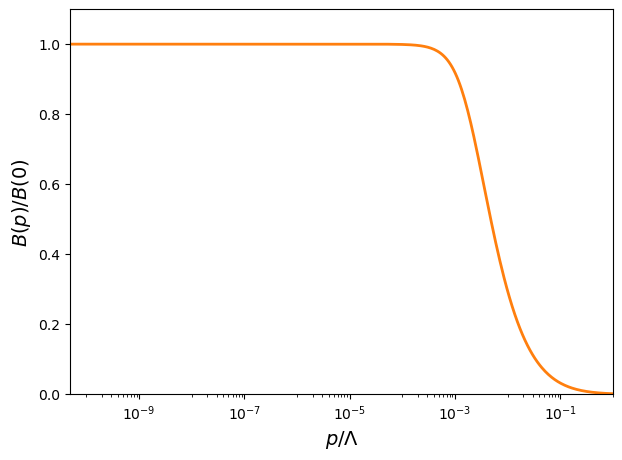

In [4]:
# B(p^2)/B(0) vs. p
plt.figure(figsize=(7,5))
plt.plot(p_vals, B_vals / B_vals[0], color="tab:orange", lw=2)
plt.xscale('log')
plt.xlim([0.5e-10, 1])
plt.ylim([0, 1.1])

ax = plt.gca()
ax.xaxis.set_minor_locator(LogLocator(base=100.0, subs=[9,8,7,6,5,4,3,2,1], numticks=100)) # mostra os minor ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())  # remove os números dos minor ticks

plt.xlabel(r"$p/\Lambda$", fontsize=14)
plt.ylabel(r"$B(p)/B(0)$", fontsize=14)
#plt.title(r"Massa Dinâmica Normalizada ", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.0)
plt.rcParams['figure.dpi'] = 300
plt.show()

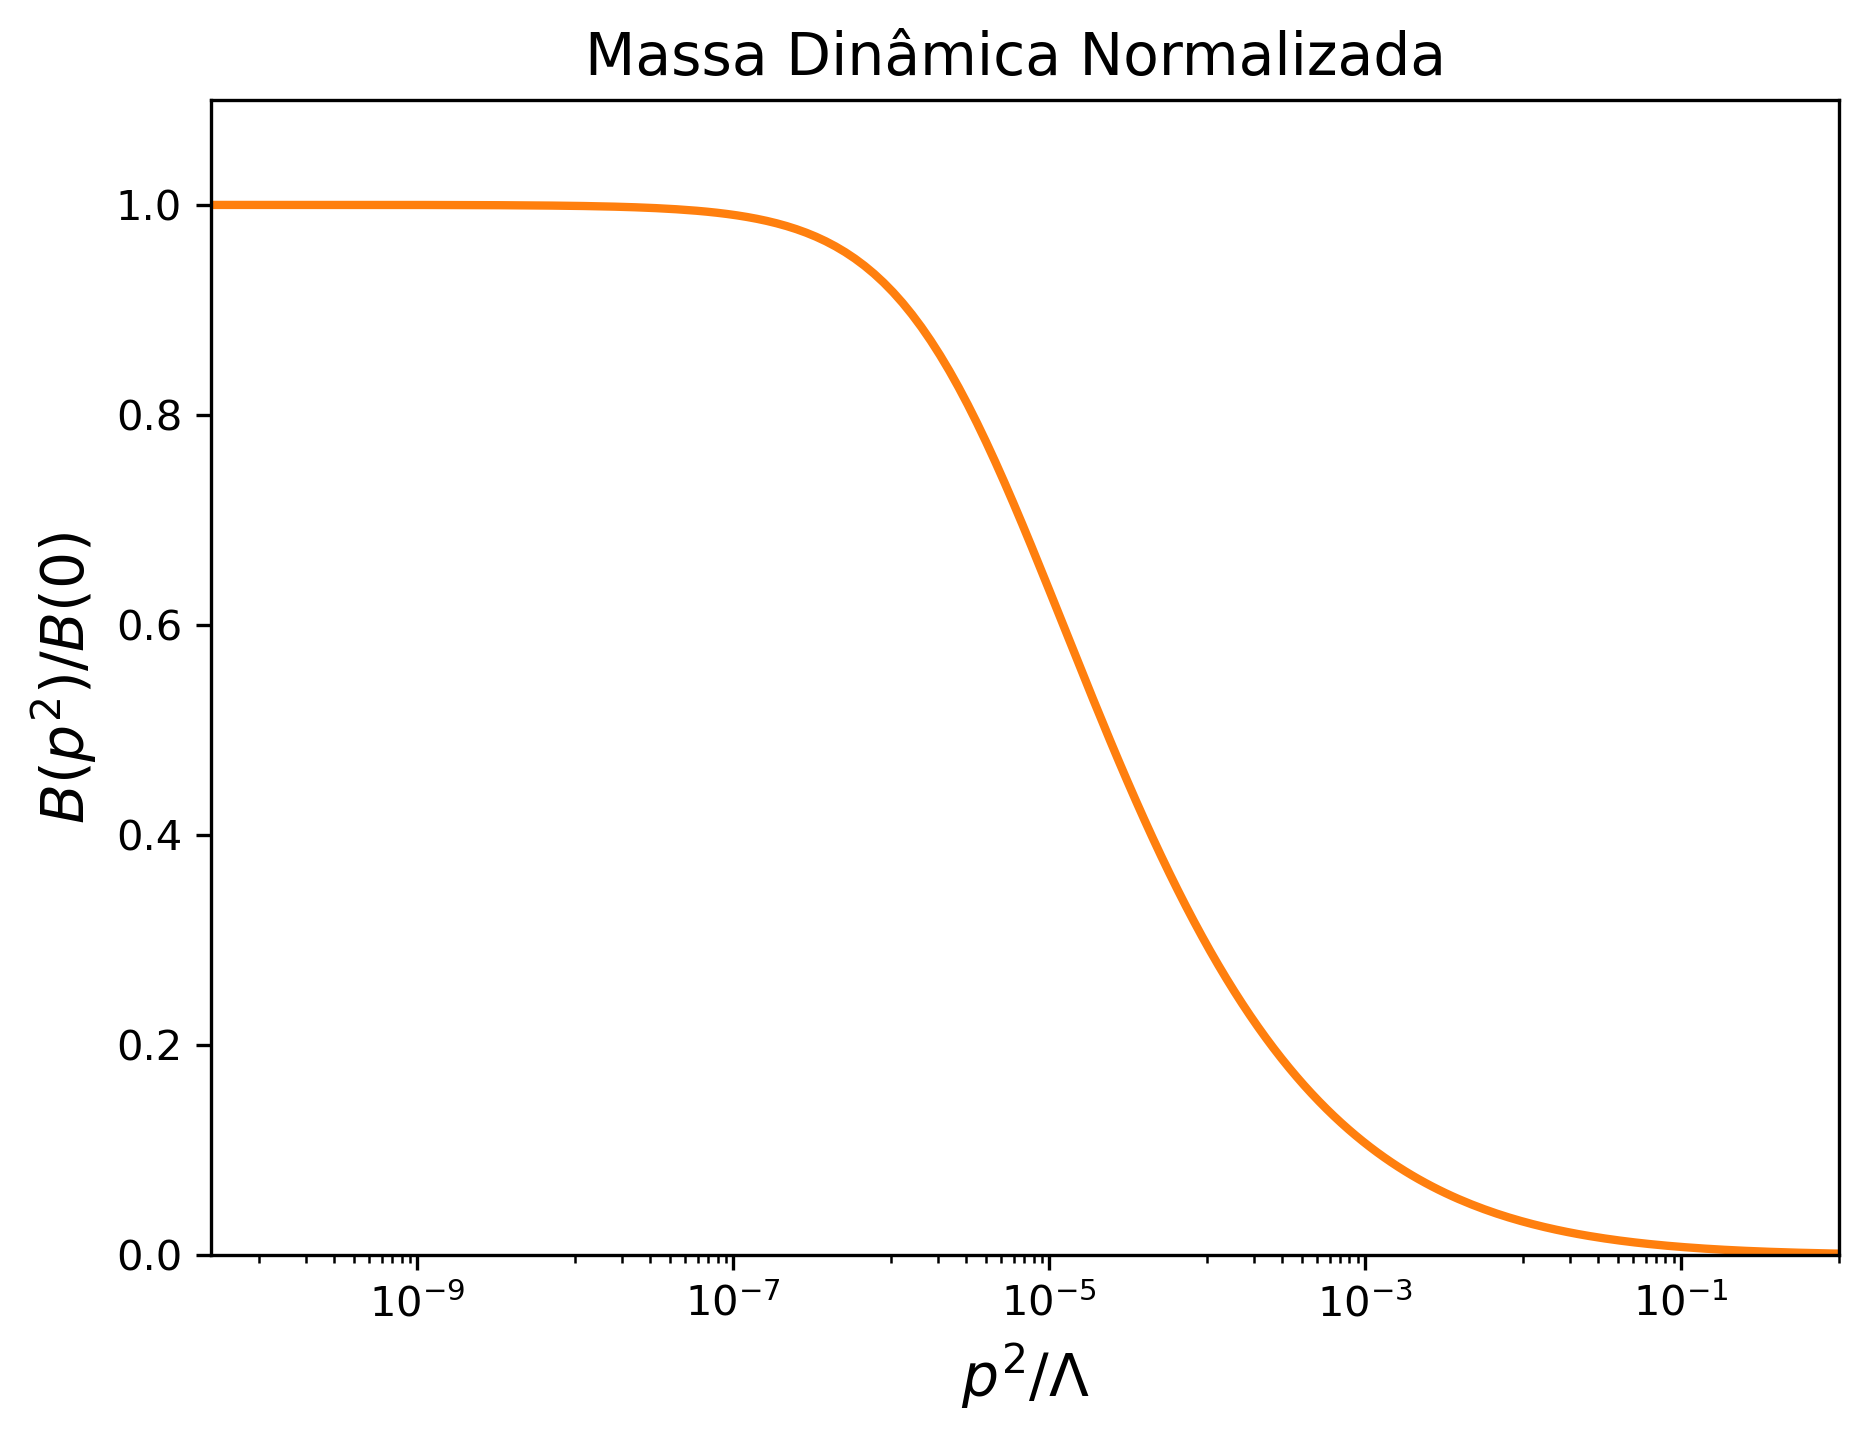

In [5]:
# B(p^2)/B(0) vs. p^2
plt.figure(figsize=(7,5))
plt.plot(p_vals**2, B_vals / B_vals[0], color="tab:orange", lw=2)
plt.xscale('log')
plt.xlim([0.5e-10, 1])
plt.ylim([0, 1.1])

ax = plt.gca()
ax.xaxis.set_minor_locator(LogLocator(base=100.0, subs=[9,8,7,6,5,4,3,2,1], numticks=100)) # mostra os minor ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())  # remove os números dos minor ticks

plt.xlabel(r"$p^2/\Lambda$", fontsize=14)
plt.ylabel(r"$B(p^2)/B(0)$", fontsize=14)
plt.title(r"Massa Dinâmica Normalizada ", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.0)
plt.show()

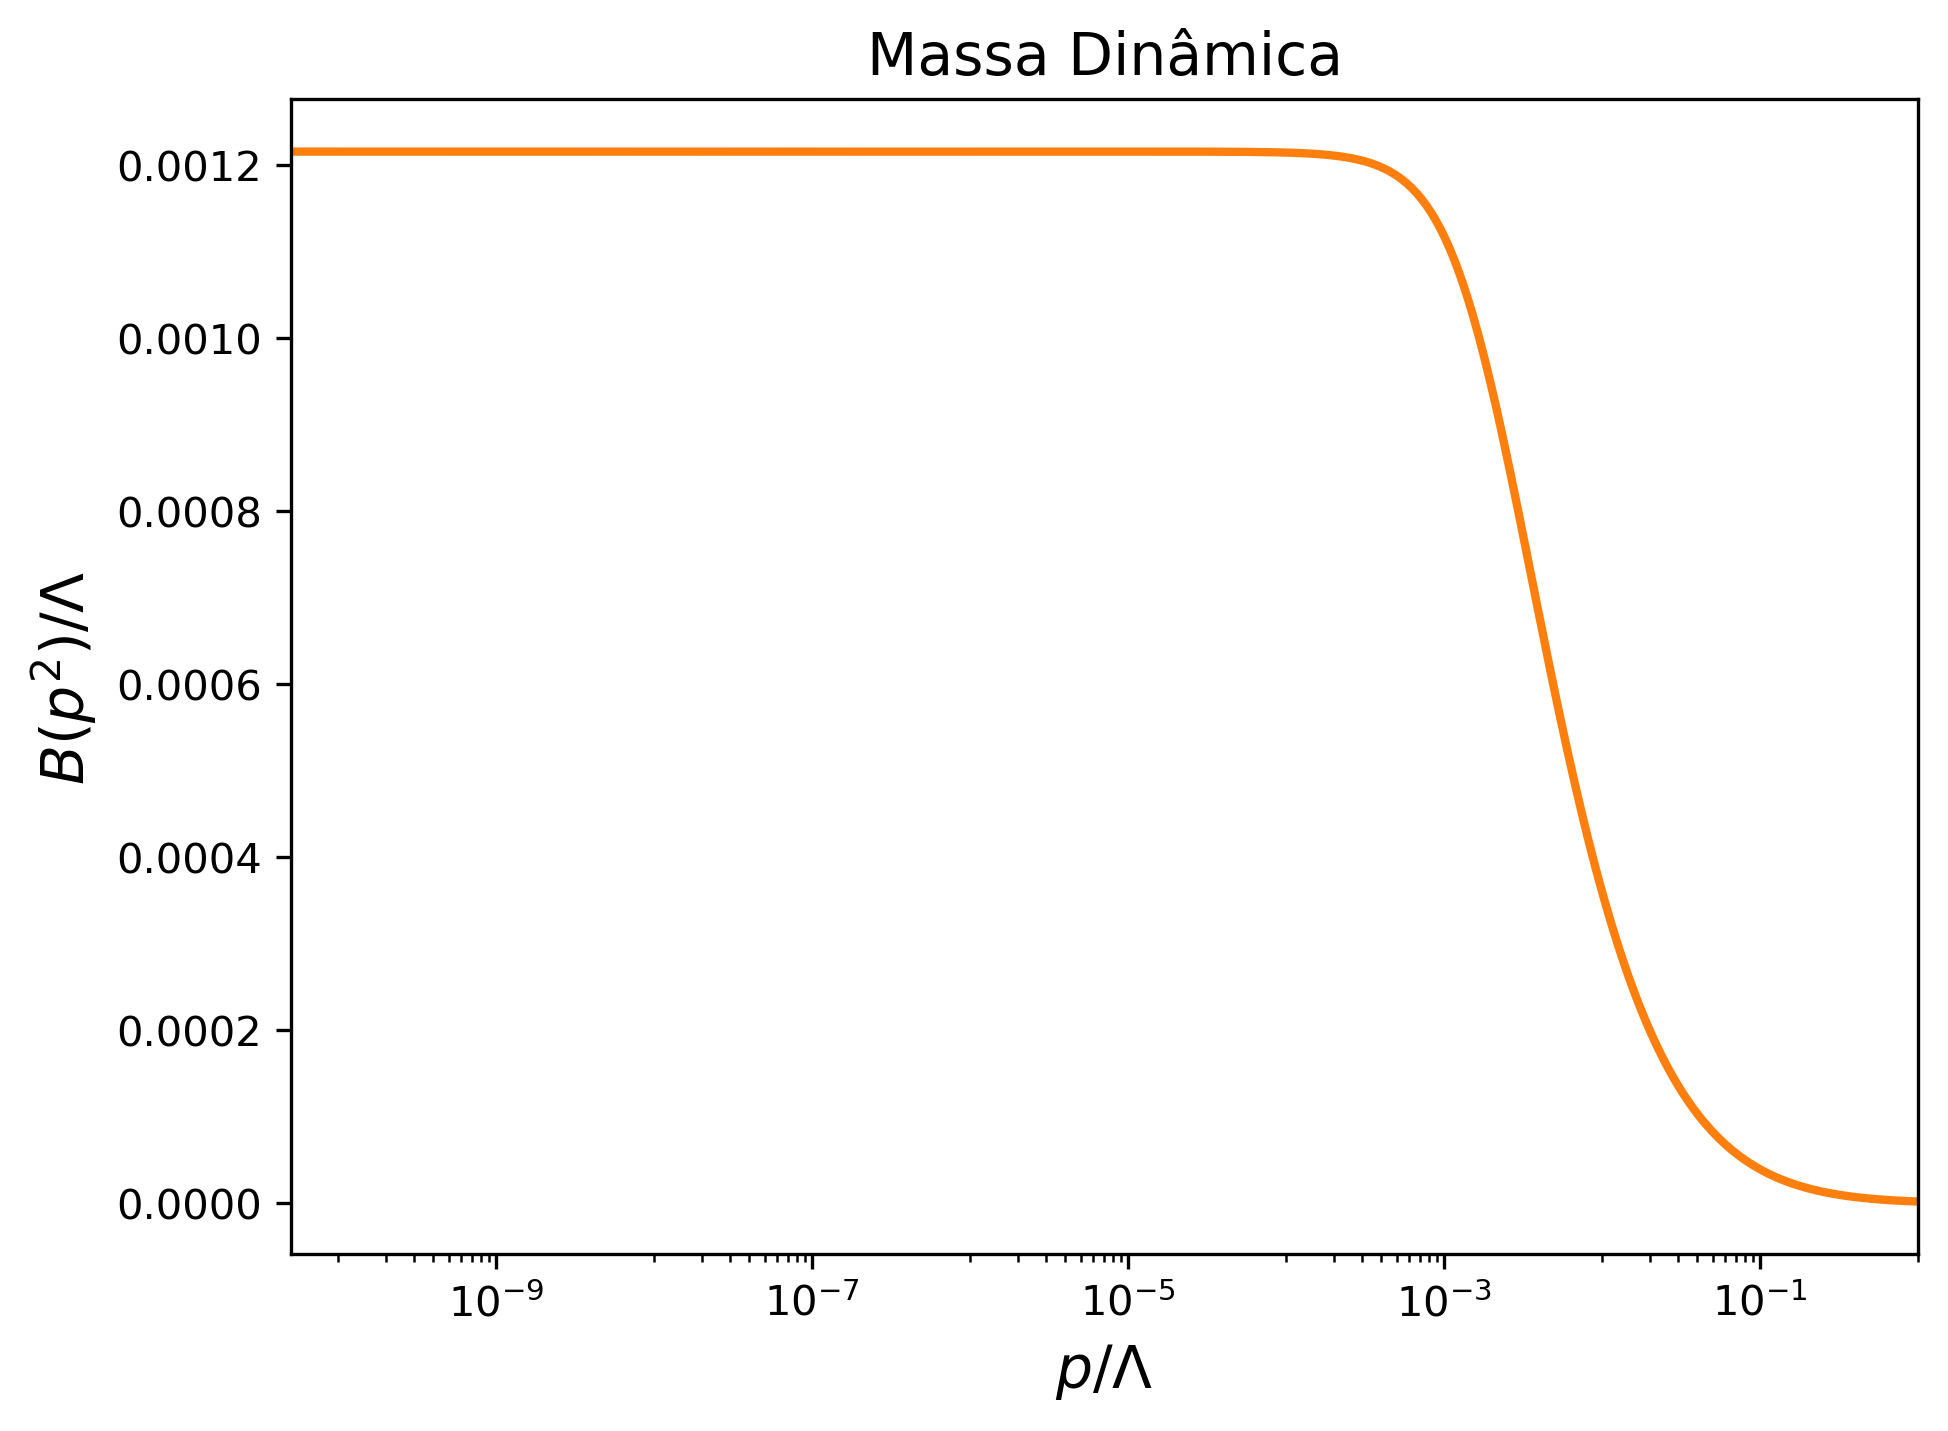

In [6]:
# B(p^2) vs. p
plt.figure(figsize=(7,5))
plt.plot(p_vals, B_vals / Lambda_UV, color="tab:orange", lw=2)
plt.xscale('log')
plt.xlim([0.5e-10, 1])
#plt.ylim([0, (B[0]+100)/Lambda_UV])

ax = plt.gca()
ax.xaxis.set_minor_locator(LogLocator(base=100.0, subs=[9,8,7,6,5,4,3,2,1], numticks=100)) # mostra os minor ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())  # remove os números dos minor ticks

plt.xlabel(r"$p/\Lambda$", fontsize=14)
plt.ylabel(r"$B(p^2)/\Lambda$", fontsize=14)
plt.title(r"Massa Dinâmica", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.0)
plt.show()

\begin{align*}
    B(x) &= m_0 + \frac{3 \bar{g}^2}{16\pi^2} \int_{\Lambda_{IR}^2}^{\Lambda_{UV}^2} \frac{y \, \mathrm{d}y}{\text{max}(x,y)} 
    \left( \frac{B(y)}{y + B^2(y)} \right)
    \\
    \Rightarrow B(p) &= m_0 + C \int_{\Lambda_{IR}}^{\Lambda_{UV}} \frac{k^2 \, \mathrm{d}k^2}{\text{max}(p^2,k^2)} 
    \left( \frac{B(k)}{k^2 + B^2(k)} \right)
    \\
    &= m_0 + 2C \int_{\Lambda_{IR}}^{\Lambda_{UV}} \frac{k^3 \, \mathrm{d}k}{\text{max}(p^2,k^2)} 
    \left( \frac{B(k)}{k^2 + B^2(k)} \right)
\end{align*}

In [7]:
# Agora com B(p) desde o início (usando p e k ao invés de x=p^2 e y=k^2)

#### Parâmetros físicos (adimensionais) ####
g2_bar = 15.0      # acoplamento (> g_c^2 = 13.15 +- 0.05)
m0 = 0.0           # massa nua
Lambda_UV = 1e5    # corte UV
Lambda_IR = 1e-9   # corte infravermelho

#### Parâmetros numéricos ####
N = 600            # pontos de Gauss-Legendre (pelo menos 500)
tol = 1e-8         # tolerância
max_iter = 1500    # número máximo de iterações
relax = 1.0        # relaxação

#### Pontos e pesos de Gauss-Legendre em z = ln(k) ####
z_min, z_max = np.log(Lambda_IR), np.log(Lambda_UV)
nodes, weights = leggauss(N)
## Mapeamento [-1,1] --> [z_min, z_max] ##
z_vals = 0.5 * (z_max - z_min) * nodes + 0.5 * (z_max + z_min)
w_z = 0.5 * (z_max - z_min) * weights
## Converter de volta para k ##
k = np.exp(z_vals)
## O peso efetivo é e^z * w_z ##
w_eff = k * w_z

#### Chute inicial ####
# B = np.ones_like(y_vals) * 1e-5 
B = np.ones_like(k) * 1e-5   # muito pequeno, mas não exatamente 0

#### Iteração de ponto fixo ####
for it in range(max_iter):
    B_new = np.zeros_like(B)
    for i, p in enumerate(k):
        integrand = (k**3 / np.maximum(p**2, k**2)) * (B / (k**2 + B**2))    # define o integrando
        integral = np.sum(w_eff * integrand)                                 # calcula a integral
        B_new[i] = m0 + 2 * (3 * g2_bar / (16 * np.pi**2)) * integral        # calcula B^(n+1)
    B_new = (1 - relax) * B + relax * B_new                                  # relaxação
    diff = np.max(np.abs(B_new - B))                                         # calcula a diferença
    if it % 10 == 0:
        print(f'Iteração {it:4d}: diferença = {diff:3e}')
    if diff < tol:
        print(f"Convergiu na iteração {it}")
        break
    B = B_new
else:
    print("Atenção: número máximo de iterações atingido")

#### Converter para p = sqrt(x) ####
p_vals = k / Lambda_UV
# p_vals = y_vals / 1e5
B_vals = B / Lambda_UV

Iteração    0: diferença = 1.212316e-04
Iteração   10: diferença = 1.658916e-02
Iteração   20: diferença = 1.774363e-02
Iteração   30: diferença = 2.180162e-02
Iteração   40: diferença = 3.029403e-02
Iteração   50: diferença = 4.316418e-02
Iteração   60: diferença = 6.096851e-02
Iteração   70: diferença = 8.454790e-02
Iteração   80: diferença = 1.147121e-01
Iteração   90: diferença = 1.520595e-01
Iteração  100: diferença = 1.967411e-01
Iteração  110: diferença = 2.483146e-01
Iteração  120: diferença = 3.055555e-01
Iteração  130: diferença = 3.664231e-01
Iteração  140: diferença = 4.283230e-01
Iteração  150: diferença = 4.880960e-01
Iteração  160: diferença = 5.425065e-01
Iteração  170: diferença = 5.885866e-01
Iteração  180: diferença = 6.238305e-01
Iteração  190: diferença = 6.467084e-01
Iteração  200: diferença = 6.566369e-01
Iteração  210: diferença = 6.538636e-01
Iteração  220: diferença = 6.395371e-01
Iteração  230: diferença = 6.153044e-01
Iteração  240: diferença = 5.833107e-01


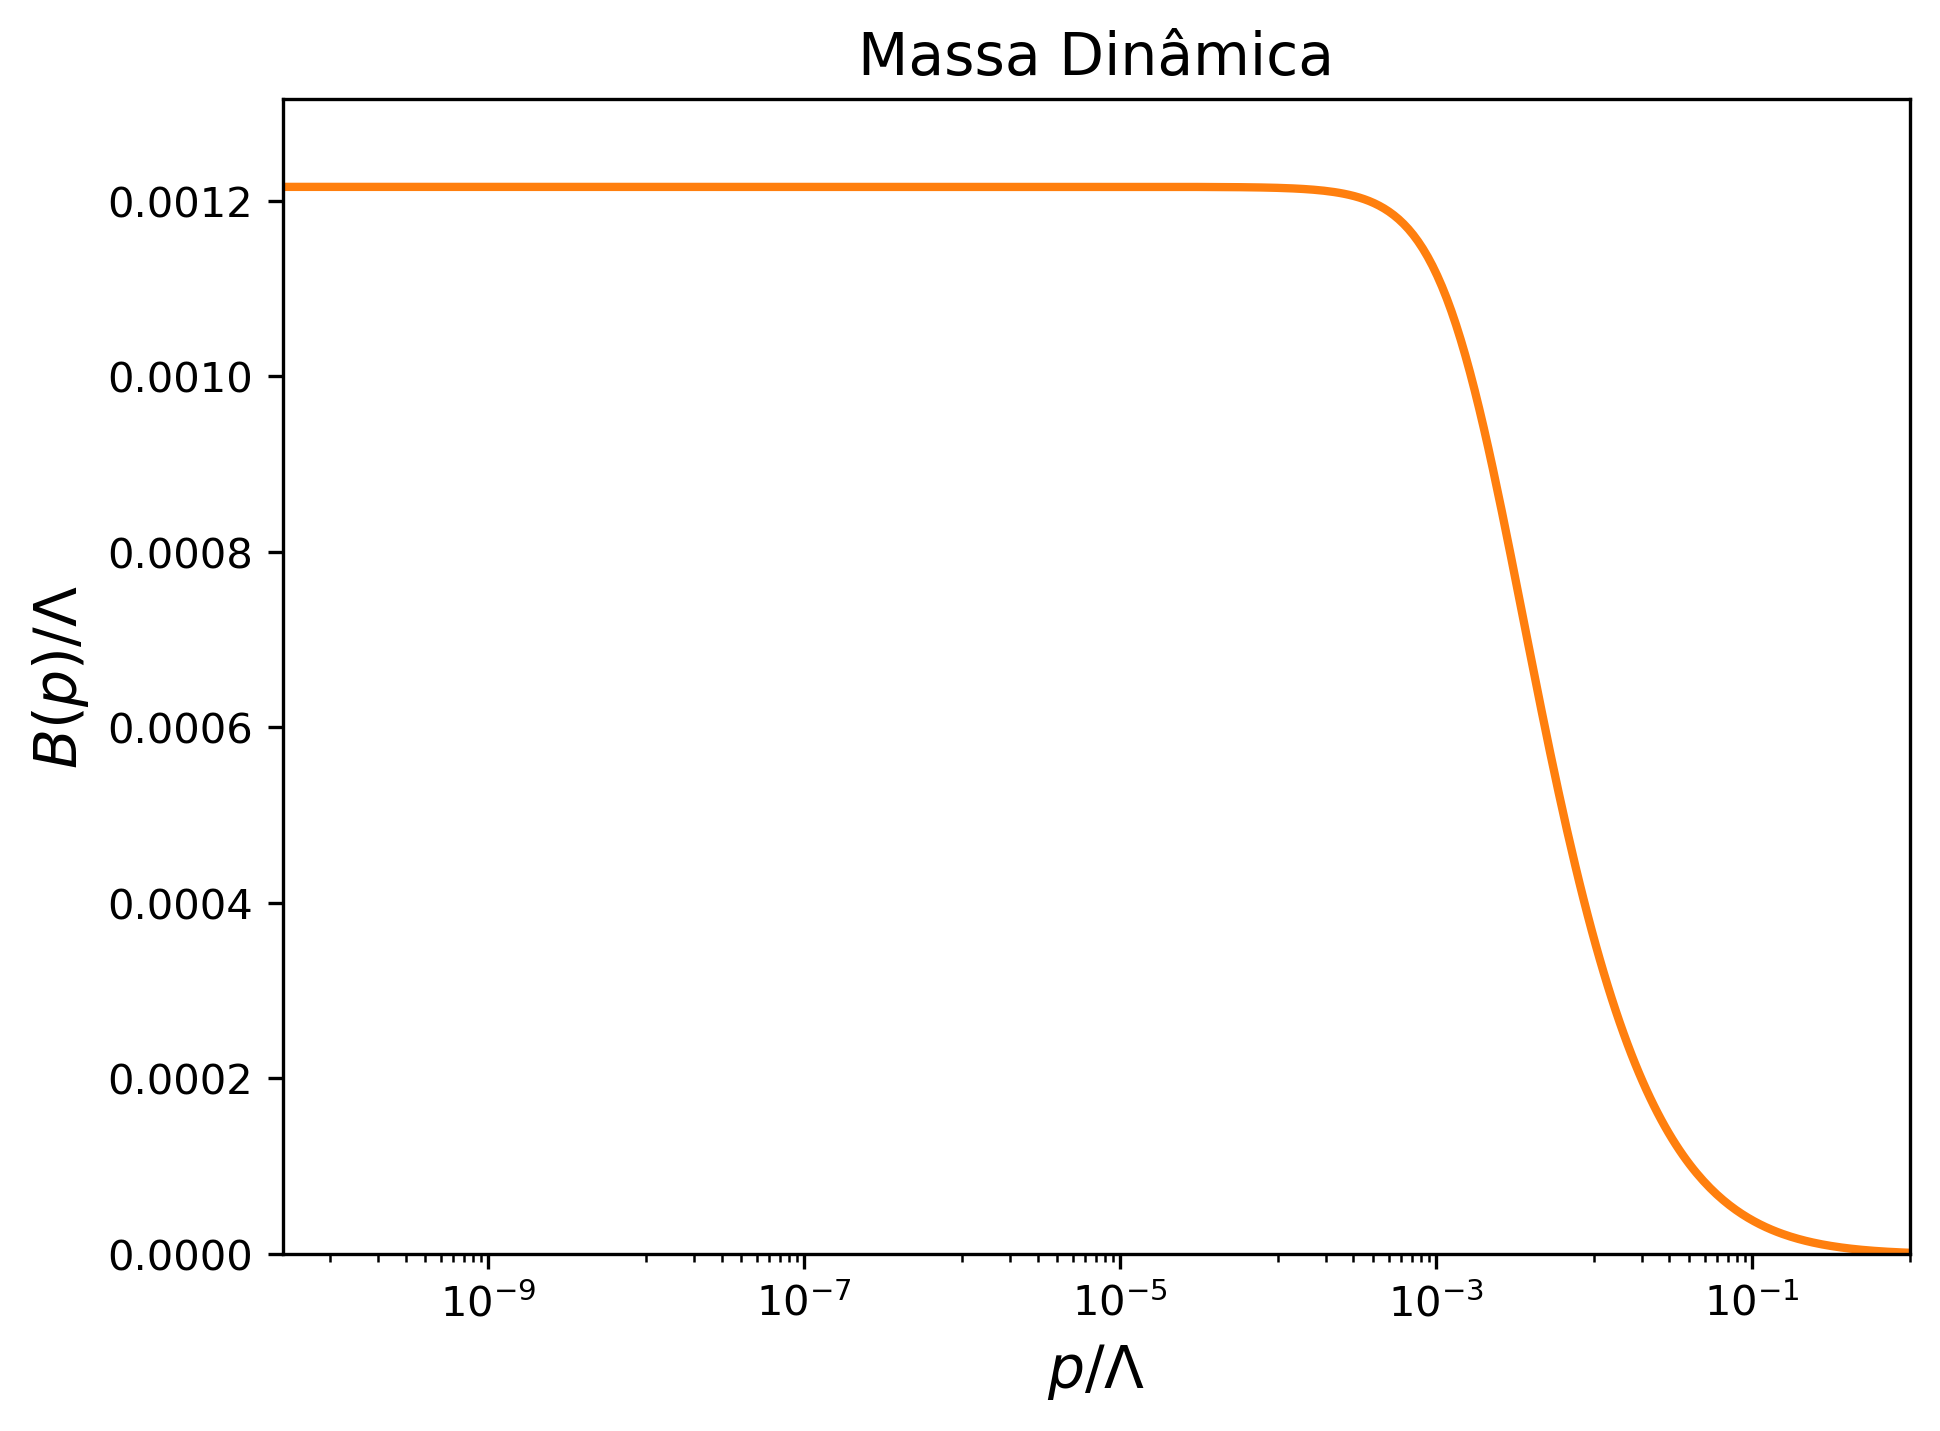

In [8]:
# B(p) vs. p
plt.figure(figsize=(7,5))
plt.plot(p_vals, B_vals, color="tab:orange", lw=2)
plt.xscale('log')
plt.xlim([0.5e-10, 1])
plt.ylim([0, (B[0]+10)/Lambda_UV])

ax = plt.gca()
ax.xaxis.set_minor_locator(LogLocator(base=100.0, subs=[9,8,7,6,5,4,3,2,1], numticks=100)) # mostra os minor ticks
ax.xaxis.set_minor_formatter(plt.NullFormatter())  # remove os números dos minor ticks

plt.xlabel(r"$p/\Lambda$", fontsize=14)
plt.ylabel(r"$B(p)/\Lambda$", fontsize=14)
plt.title(r"Massa Dinâmica", fontsize=14)
plt.grid(True, which="both", ls=":", alpha=0.0)
plt.show()

In [9]:
1.2e-3 / 2.8e-5

42.857142857142854

In [10]:
(3 * g2_bar / (16 * np.pi**2)) / (3 * g2_bar**2 / (16 * np.pi**2))

0.06666666666666668